# Lesson 09 — Calculus Intuition

**What this notebook does:** builds a one-knob urgency scorer for support tickets, measures how wrong it is with a *loss*, measures the loss's *slope* by nudging the knob (no formulas needed), then walks downhill to the best setting with *gradient descent*. Along the way it plots the walk, deliberately breaks it with a too-big learning rate, and finishes with two knobs at once — which is where the *gradient* appears.

Run the cells top to bottom.

## One knob to tune

Four support tickets, described by a single signal each: how many urgent-sounding words they contain (`urgent_words`). A human has already assigned each one a "true" urgency score (`true_urgency`) — this tiny made-up dataset is our ground truth.

Our scorer has exactly **one knob**: a weight `w`. Its prediction for every ticket is simply `w × urgent_words` — Lesson 08's weighted-signals idea, cut down to one signal so we can watch the knob clearly.

To tune the knob we first need a way to measure *how wrong* a given setting is. That measuring stick is the **loss**: for each ticket, take `(prediction − truth)`, **square it** (so overshooting and undershooting both count as wrong, and big misses count extra), then **average** over all tickets. One number out: `0` means a perfect scorer, bigger means worse.

The cell below tries four knob settings by hand. Watch which one wins.

In [91]:
import numpy as np

urgent_words = np.array([0, 1, 2, 4])
true_urgency = np.array([0, 2, 4, 8])

def predict(w):
    return w * urgent_words

def loss(w):
    return ((predict(w) - true_urgency) ** 2).mean()

def explain_loss(w):
    predictions = predict(w)
    errors = predictions - true_urgency
    squared_errors = errors ** 2
    result = squared_errors.mean()

    print(f"=== loss check at w = {w} ===")
    print(f"step 1: predict  -> w * urgent_words       = {w} * {urgent_words.tolist()} = {predictions.tolist()}")
    print(f"step 2: compare  -> prediction - truth      = {predictions.tolist()} - {true_urgency.tolist()} = {errors.tolist()}")
    print(f"step 3: square   -> errors ** 2              = {errors.tolist()} ** 2 = {squared_errors.tolist()}")
    print(f"step 4: average  -> mean(squared errors)     = {result}")
    print()
    return result

print("Trying four knob settings by hand:")
for guess in [0.0, 1.0, 2.0, 3.0]:
    explain_loss(guess)

Trying four knob settings by hand:
=== loss check at w = 0.0 ===
step 1: predict  -> w * urgent_words       = 0.0 * [0, 1, 2, 4] = [0.0, 0.0, 0.0, 0.0]
step 2: compare  -> prediction - truth      = [0.0, 0.0, 0.0, 0.0] - [0, 2, 4, 8] = [0.0, -2.0, -4.0, -8.0]
step 3: square   -> errors ** 2              = [0.0, -2.0, -4.0, -8.0] ** 2 = [0.0, 4.0, 16.0, 64.0]
step 4: average  -> mean(squared errors)     = 21.0

=== loss check at w = 1.0 ===
step 1: predict  -> w * urgent_words       = 1.0 * [0, 1, 2, 4] = [0.0, 1.0, 2.0, 4.0]
step 2: compare  -> prediction - truth      = [0.0, 1.0, 2.0, 4.0] - [0, 2, 4, 8] = [0.0, -1.0, -2.0, -4.0]
step 3: square   -> errors ** 2              = [0.0, -1.0, -2.0, -4.0] ** 2 = [0.0, 1.0, 4.0, 16.0]
step 4: average  -> mean(squared errors)     = 5.25

=== loss check at w = 2.0 ===
step 1: predict  -> w * urgent_words       = 2.0 * [0, 1, 2, 4] = [0.0, 2.0, 4.0, 8.0]
step 2: compare  -> prediction - truth      = [0.0, 2.0, 4.0, 8.0] - [0, 2, 4, 8] = [0.0, 0

## Measuring the slope by nudging

Guessing knob settings one at a time is blind. The smarter question to ask at any current setting is: *"if I turn the knob a tiny bit to the right, does the loss go up or down — and how fast?"*

That number is the **slope** of the loss at that point (its formal name is the *derivative*). And we can measure it with no formulas at all:

1. Nudge `w` a hair **up**, to `w + nudge`, and compute the loss there.
2. Nudge `w` the same hair **down**, to `w - nudge`, and compute the loss there.
3. Subtract, and divide by the distance between the two nudged points.

That is literally "rise over run" from school — the same idea as the slope between any two points on any curve — just applied to two points sitting extremely close together (we use a gap of `0.0001` on each side).

**Where the `2 * nudge` in the code comes from.** It is not a special constant — it is just the actual distance between the two points we sampled. `w - nudge` and `w + nudge` sit `2 * nudge` apart on the number line, so "run" has to be `2 * nudge` for "rise over run" to be honest about the distance it's dividing by:

```
rise = loss(w + nudge) - loss(w - nudge)
run  = (w + nudge) - (w - nudge) = 2 * nudge
slope = rise / run
```

**Why straddle `w` instead of the simpler "compare `w` to `w + nudge`"?** That simpler version (called a *forward difference*) only looks ahead of `w`, never behind it, so if the curve is bending, the estimate leans slightly the wrong way. Straddling — one point behind, one ahead, `w` exactly in the middle — cancels out most of that bend automatically. A quick check with a curve whose real slope we already know, `f(x) = x²` (true slope at `x = 1` is exactly `2`), using a nudge of `0.1` so the effect is visible:

- Forward version (`1` vs `1.1`): `(f(1.1) - f(1)) / 0.1 = (1.21 - 1.00) / 0.1 = 2.1` — off by `0.1`.
- Straddling version (`0.9` vs `1.1`): `(f(1.1) - f(0.9)) / (2 × 0.1) = (1.21 - 0.81) / 0.2 = 2.0` — exactly right.

Looking equally far in both directions makes the curve's bend on the left and its bend on the right cancel out, which is why the notebook nudges both up *and* down instead of just up. The cost is one extra call to `loss` per slope check — cheap here, but part of why nobody nudges knobs one at a time once a model has millions of them (that's what backpropagation, in Phase 3, solves instead).

Read the result like this:

- **Sign** = direction: a *negative* slope means the loss falls as `w` grows (downhill is to the right); a *positive* slope means downhill is to the left.
- **Size** = steepness: a slope of `-21` means the loss is falling steeply; `-0.01` means the ground is nearly flat.

Check the printed values against the previous cell: at `w = 0` the loss is falling fast toward the right (we saw 21.0 drop to 5.25), and at `w = 3` it rises to the right — both signs will match what the numbers already showed.

In [92]:
def slope(w, nudge=0.0001):
    return (loss(w + nudge) - loss(w - nudge)) / (2 * nudge)

def explain_slope(w, nudge=0.0001):
    w_up, w_down = w + nudge, w - nudge
    loss_up, loss_down = loss(w_up), loss(w_down)
    rise = loss_up - loss_down
    run = 2 * nudge
    result = rise / run

    print(f"=== slope check at w = {w} ===")
    print(f"step 1: nudge up    -> w + nudge = {w_up}")
    print(f"step 2: nudge down  -> w - nudge = {w_down}")
    print(f"step 3: loss at each point")
    print(f"    loss(w + nudge) = {loss_up:.6f}")
    print(f"    loss(w - nudge) = {loss_down:.6f}")
    print(f"step 4: rise / run")
    print(f"    rise  = loss(w+nudge) - loss(w-nudge) = {rise:.6f}")
    print(f"    run   = 2 * nudge                      = {run}")
    print(f"    slope = rise / run                     = {result:.3f}")
    print()
    return result

for point in [0.0, 1.0, 3.0]:
    explain_slope(point)

=== slope check at w = 0.0 ===
step 1: nudge up    -> w + nudge = 0.0001
step 2: nudge down  -> w - nudge = -0.0001
step 3: loss at each point
    loss(w + nudge) = 20.997900
    loss(w - nudge) = 21.002100
step 4: rise / run
    rise  = loss(w+nudge) - loss(w-nudge) = -0.004200
    run   = 2 * nudge                      = 0.0002
    slope = rise / run                     = -21.000

=== slope check at w = 1.0 ===
step 1: nudge up    -> w + nudge = 1.0001
step 2: nudge down  -> w - nudge = 0.9999
step 3: loss at each point
    loss(w + nudge) = 5.248950
    loss(w - nudge) = 5.251050
step 4: rise / run
    rise  = loss(w+nudge) - loss(w-nudge) = -0.002100
    run   = 2 * nudge                      = 0.0002
    slope = rise / run                     = -10.500

=== slope check at w = 3.0 ===
step 1: nudge up    -> w + nudge = 3.0001
step 2: nudge down  -> w - nudge = 2.9999
step 3: loss at each point
    loss(w + nudge) = 5.251050
    loss(w - nudge) = 5.248950
step 4: rise / run
    rise

## Walking downhill: gradient descent

Now use the slope to *improve* the knob automatically. The recipe:

1. Measure the slope at the current `w`.
2. Take a small step in the **opposite** direction — slope negative means loss falls to the right, so step right; slope positive, step left. In code both cases collapse into one line: `w = w - learning_rate * slope`.
3. Repeat.

The **learning rate** is the step size — how big a fraction of the slope we actually move. We use `0.05` here.

This recipe is called **gradient descent**, and it is *the* algorithm by which almost every model in this course learns, from Phase 2's regressions to the largest language models.

Watch the printout: `w` climbs from `0` toward `2`, the loss collapses toward `0`, and the steps shrink on their own — because the valley gets flatter near the bottom, the measured slope shrinks, so `learning_rate × slope` shrinks too. Nobody schedules that; it falls out of the math.

In [93]:
w = 0.0
learning_rate = 0.05
path = [w]

print(f"start: w = {w:.3f}, loss = {explain_loss(w):.3f}")
print()

for step in range(1, 21):
    current_slope = explain_slope(w)
    step_taken = learning_rate * current_slope
    w = w - step_taken
    path.append(w)
    if step <= 5 or step % 5 == 0:
        print(f"step {step:2d}:")
        print(f"    slope at w        = {current_slope:.3f}")
        print(f"    step = lr * slope = {learning_rate} * {current_slope:.3f} = {step_taken:.3f}")
        print(f"    w = w - step      = {w:.3f}")
        print(f"    loss at new w     = {explain_loss(w):.3f}")
        print()

=== loss check at w = 0.0 ===
step 1: predict  -> w * urgent_words       = 0.0 * [0, 1, 2, 4] = [0.0, 0.0, 0.0, 0.0]
step 2: compare  -> prediction - truth      = [0.0, 0.0, 0.0, 0.0] - [0, 2, 4, 8] = [0.0, -2.0, -4.0, -8.0]
step 3: square   -> errors ** 2              = [0.0, -2.0, -4.0, -8.0] ** 2 = [0.0, 4.0, 16.0, 64.0]
step 4: average  -> mean(squared errors)     = 21.0

start: w = 0.000, loss = 21.000

=== slope check at w = 0.0 ===
step 1: nudge up    -> w + nudge = 0.0001
step 2: nudge down  -> w - nudge = -0.0001
step 3: loss at each point
    loss(w + nudge) = 20.997900
    loss(w - nudge) = 21.002100
step 4: rise / run
    rise  = loss(w+nudge) - loss(w-nudge) = -0.004200
    run   = 2 * nudge                      = 0.0002
    slope = rise / run                     = -21.000

step  1:
    slope at w        = -21.000
    step = lr * slope = 0.05 * -21.000 = -1.050
    w = w - step      = 1.050
=== loss check at w = 1.0500000000011056 ===
step 1: predict  -> w * urgent_words  

## Seeing the walk

One picture makes the whole lesson click. Compute the loss for every value of `w` between `-0.5` and `4.5` and plot it — you get a **valley** with its bottom exactly at `w = 2`. Then mark every stop from our descent on top of it.

Two things to look for in the picture:

- The red dots start high on the left wall and slide down to the bottom.
- The dots are **far apart at first and bunch up near the bottom** — nobody told the walk to slow down; the flattening slope did that automatically.

The figure is also saved as a PNG in a `plots/` folder next to this notebook (same pattern as Lesson 07).

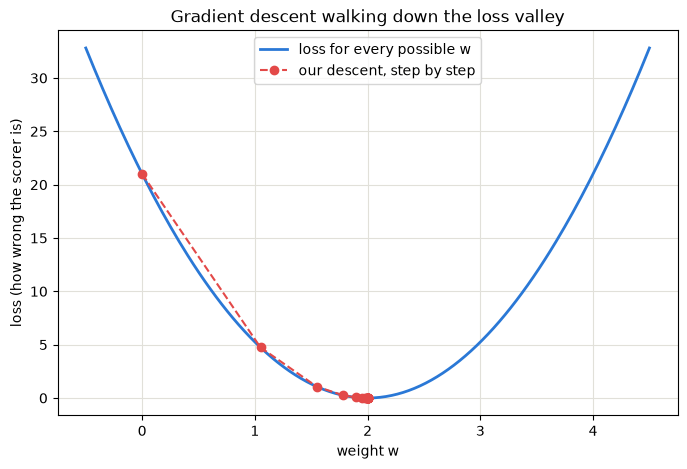

In [94]:
import matplotlib.pyplot as plt
from pathlib import Path

Path("plots").mkdir(exist_ok=True)

ws = np.linspace(-0.5, 4.5, 200)
curve = [loss(v) for v in ws]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ws, curve, color="#2a78d6", linewidth=2, label="loss for every possible w")
ax.plot(path, [loss(v) for v in path], "o--", color="#e34948",
        markersize=6, linewidth=1.5, label="our descent, step by step")
ax.set_xlabel("weight w")
ax.set_ylabel("loss (how wrong the scorer is)")
ax.set_title("Gradient descent walking down the loss valley")
ax.grid(color="#e1e0d9", linewidth=0.8)
ax.legend()
fig.savefig("plots/lesson-09-gradient-descent.png", dpi=150, bbox_inches="tight")
plt.show()

## When the step is too big

The learning rate is a real choice, and here is what happens when it is chosen badly. With `0.2` instead of `0.05`, every step *overshoots* the bottom of the valley and lands higher up the opposite wall. From there the slope is even steeper, so the next step overshoots even more.

Watch `w` bounce from one side of `2.0` to the other while the loss **grows** every step instead of shrinking. This is called *diverging*, and it is one of the most common ways training a real model fails.

In [95]:
w = 0.0
too_big = 0.2

print(f"start: w = {w:.3f}, loss = {loss(w):.3f}")
print()

for step in range(1, 7):
    current_slope = slope(w)
    step_taken = too_big * current_slope
    w = w - step_taken
    print(f"step {step}:")
    print(f"    slope at w        = {current_slope:.3f}")
    print(f"    step = lr * slope = {too_big} * {current_slope:.3f} = {step_taken:.3f}")
    print(f"    w = w - step      = {w:.3f}")
    print(f"    loss at new w     = {loss(w):.3f}")
    print()

start: w = 0.000, loss = 21.000

step 1:
    slope at w        = -21.000
    step = lr * slope = 0.2 * -21.000 = -4.200
    w = w - step      = 4.200
    loss at new w     = 25.410

step 2:
    slope at w        = 23.100
    step = lr * slope = 0.2 * 23.100 = 4.620
    w = w - step      = -0.420
    loss at new w     = 30.746

step 3:
    slope at w        = -25.410
    step = lr * slope = 0.2 * -25.410 = -5.082
    w = w - step      = 4.662
    loss at new w     = 37.203

step 4:
    slope at w        = 27.951
    step = lr * slope = 0.2 * 27.951 = 5.590
    w = w - step      = -0.928
    loss at new w     = 45.015

step 5:
    slope at w        = -30.746
    step = lr * slope = 0.2 * -30.746 = -6.149
    w = w - step      = 5.221
    loss at new w     = 54.469

step 6:
    slope at w        = 33.821
    step = lr * slope = 0.2 * 33.821 = 6.764
    w = w - step      = -1.543
    loss at new w     = 65.907



## Two knobs at once: the gradient

Real models have many knobs, not one. To see what changes, give the scorer a second knob: a **baseline** `b` added to every prediction, so `prediction = w × urgent_words + b`. The new targets below follow the pattern `2 × urgent_words + 1`, so the best setting is `w = 2, b = 1` — but the code does not know that; it has to find it.

With two knobs, "the slope" becomes **two slopes**: nudge only `w` to ask "does loss drop if I turn the weight knob?", then nudge only `b` to ask the same about the baseline knob. Each is called a *partial* slope because it nudges one knob while holding the other still.

The list of all the slopes, one per knob, is the **gradient** — and a list of numbers with fixed positions is exactly a *vector* from Lesson 08. The gradient vector points in the direction that makes the loss grow fastest, so stepping *against* it is the fastest way down.

The recipe does not change at all: measure every slope, step every knob opposite its own slope, repeat. That, scaled up, is how every neural network learns.

In [96]:
true_urgency_2 = np.array([1, 3, 5, 9])

def loss2(w, b):
    return ((w * urgent_words + b - true_urgency_2) ** 2).mean()

def slope_w(w, b, nudge=0.0001):
    return (loss2(w + nudge, b) - loss2(w - nudge, b)) / (2 * nudge)

def slope_b(w, b, nudge=0.0001):
    return (loss2(w, b + nudge) - loss2(w, b - nudge)) / (2 * nudge)

w, b = 0.0, 0.0
print(f"start: w = {w:.3f}, b = {b:.3f}, loss = {loss2(w, b):.3f}")
print(f"gradient at start: [slope_w, slope_b] = [{slope_w(w, b):.1f}, {slope_b(w, b):.1f}]")
print()

for step in range(1, 401):
    grad_w = slope_w(w, b)
    grad_b = slope_b(w, b)
    w = w - 0.05 * grad_w
    b = b - 0.05 * grad_b
    if step in (1, 50, 100, 200, 400):
        print(f"step {step:3d}:")
        print(f"    gradient = [slope_w, slope_b] = [{grad_w:.3f}, {grad_b:.3f}]")
        print(f"    w = {w:.3f}, b = {b:.3f}, loss = {loss2(w, b):.3f}")
        print()

start: w = 0.000, b = 0.000, loss = 29.000
gradient at start: [slope_w, slope_b] = [-24.5, -9.0]

step   1:
    gradient = [slope_w, slope_b] = [-24.500, -9.000]
    w = 1.225, b = 0.450, loss = 4.948

step  50:
    gradient = [slope_w, slope_b] = [0.010, -0.029]
    w = 2.013, b = 0.962, loss = 0.001

step 100:
    gradient = [slope_w, slope_b] = [0.002, -0.004]
    w = 2.002, b = 0.994, loss = 0.000

step 200:
    gradient = [slope_w, slope_b] = [0.000, -0.000]
    w = 2.000, b = 1.000, loss = 0.000

step 400:
    gradient = [slope_w, slope_b] = [0.000, -0.000]
    w = 2.000, b = 1.000, loss = 0.000



## What this means for real models

Everything a neural network does during training is this exact game, scaled up:

- A real model has **millions (or billions) of knobs** instead of two. They are called parameters or weights.
- Training is: compute the loss on real data, get the gradient (one slope per knob), step every knob a little bit opposite its slope, repeat — often millions of times.
- Nudging each knob one at a time, like we did here, would be far too slow for millions of knobs. **Backpropagation** (Phase 3) is a clever bookkeeping method that computes every slope in a single pass. The *idea* is exactly what you just did — only the bookkeeping is faster.

Notice also that two knobs needed 400 steps where one knob needed 20. Knobs interact, and the valley gets trickier to walk as the count grows — that is why Phase 3 spends a whole lesson on making training work well.